In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error,mean_absolute_error

In [ ]:
df =pd.read_csv(r'C:\Users\Sattanathan.S\Downloads\Python Projects\insurance.csv')

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:

df['region'].nunique()

4

In [ ]:
df['sex'].nunique()

2

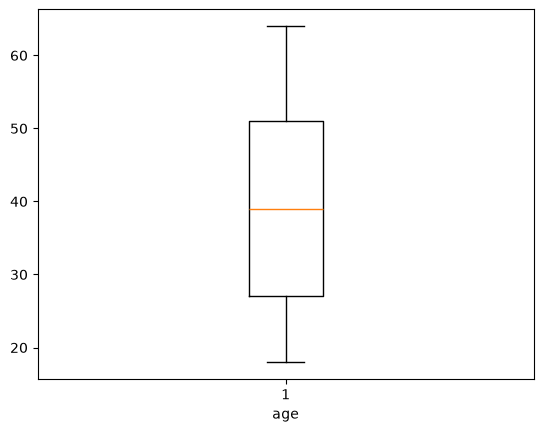

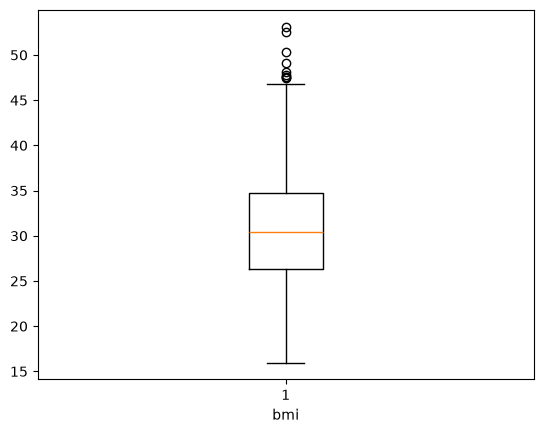

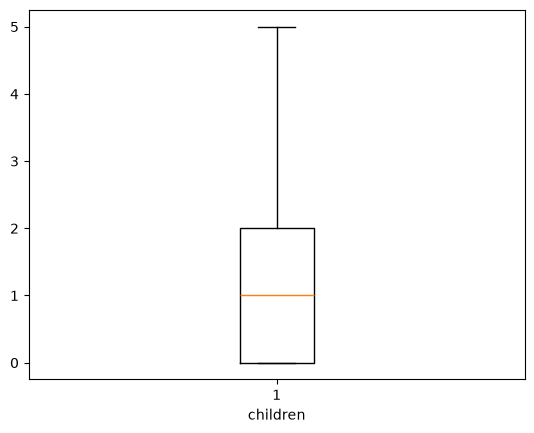

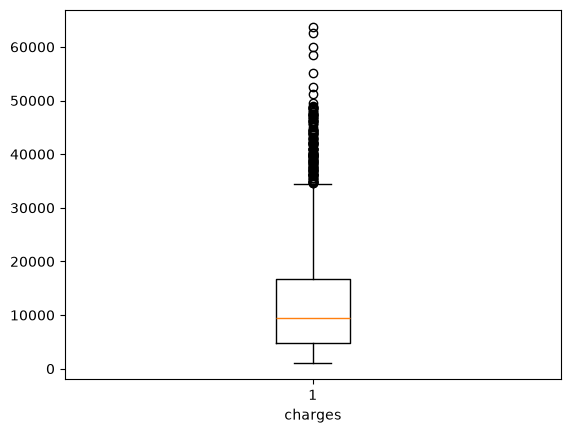

In [ ]:
for i in df.columns:
 if(df[i].dtypes != 'str'):
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()


In [ ]:
Q1= df.bmi.quantile(0.25)
Q3 =df.bmi.quantile(0.75)
IQR = Q3 -Q1

LB = Q1-1.5*IQR
UB = Q3 - 1.5* IQR
df= df[(df['bmi']>=LB)&(df['bmi']<=UB)]


In [ ]:
LB

np.float64(13.7)

In [ ]:
UB

np.float64(22.0975)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 98 entries, 28 to 1316
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       98 non-null     int64  
 1   sex       98 non-null     str    
 2   bmi       98 non-null     float64
 3   children  98 non-null     int64  
 4   smoker    98 non-null     str    
 5   region    98 non-null     str    
 6   charges   98 non-null     float64
dtypes: float64(2), int64(2), str(3)
memory usage: 7.7 KB


In [ ]:
cat_cols = ['sex','smoker','region']
le =LabelEncoder()
for cols in cat_cols:
    df[cols]=le.fit_transform(df[cols])

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 98 entries, 28 to 1316
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       98 non-null     int64  
 1   sex       98 non-null     int64  
 2   bmi       98 non-null     float64
 3   children  98 non-null     int64  
 4   smoker    98 non-null     int64  
 5   region    98 non-null     int64  
 6   charges   98 non-null     float64
dtypes: float64(2), int64(5)
memory usage: 6.1 KB


In [ ]:
df.head(5)
        

,age,sex,bmi,children,smoker,region,charges
28,23,1,17.385,1,0,1,2775.19215
35,19,1,20.425,0,0,1,1625.43375
37,26,1,20.800,0,0,3,2302.30000
42,41,1,21.780,1,0,2,6272.47720
98,56,1,19.950,0,1,0,22412.64850


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [ ]:
x =df.drop('charges', axis= True)
y=df['charges']

In [ ]:
x

,age,sex,bmi,children,smoker,region
28,23,1,17.385,1,0,1
35,19,1,20.425,0,0,1
37,26,1,20.800,0,0,3
42,41,1,21.780,1,0,2
98,56,1,19.950,0,1,0
...,...,...,...,...,...,...
1290,38,0,19.950,2,0,0
1295,20,1,22.000,1,0,3
1302,25,0,20.800,1,0,3
1306,29,0,21.850,0,1,0


In [ ]:
y

28       2775.19215
35       1625.43375
37       2302.30000
42       6272.47720
98      22412.64850
           ...     
1290     7133.90250
1295     1964.78000
1302     3208.78700
1306    16115.30450
1316     1731.67700
Name: charges, Length: 98, dtype: float64

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size= 0.2,random_state= 42)

In [ ]:
x_train

,age,sex,bmi,children,smoker,region
793,53,1,20.900,0,1,2
1074,60,0,18.335,0,0,0
1054,27,0,21.470,0,0,1
266,40,1,19.800,1,1,2
613,34,0,19.000,3,0,0
...,...,...,...,...,...,...
989,24,0,20.520,0,1,0
1080,18,1,21.780,2,0,2
250,18,1,17.290,2,1,0
1286,28,0,17.290,0,0,0


In [ ]:
y_train

793     21195.81800
1074    13204.28565
1054     3353.47030
266     17179.52200
613      6753.03800
           ...     
989     14571.89080
1080    11884.04858
250     12829.45510
1286     3732.62510
821      2680.94930
Name: charges, Length: 78, dtype: float64

In [ ]:
model = RandomForestRegressor(n_estimators=500,max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [ ]:
predict =model.predict(x_test)

In [ ]:
result = pd.DataFrame(columns=['Actual','Predicted'])
result['Actual'] =y_test
result['Predicted']= predict
print(result)

           Actual     Predicted
994   16420.49455  16951.847959
622    9182.17000   9767.210800
1295   1964.78000   3083.404895
359    1607.51010   3006.568479
1194   4134.08245   4810.137191
1212   1702.45530   3192.219105
1011  18767.73770  21023.765059
680    2585.26900   2889.050266
182    4005.42250   4816.201063
28     2775.19215   7846.697841
431    4906.40965   4809.514932
1109   8605.36150   8072.061868
747    1627.28245   3758.021496
408    6652.52880   6564.707176
684    4766.02200   5209.208934
98    22412.64850  19268.469403
380   15006.57945  16875.576445
232    1727.78500   2005.977340
1260   4544.23480   4494.289208
1085  19023.26000  21558.613887


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
score = r2_score(y_test,predict)
mse =mean_squared_error(y_test,predict)
rmse= root_mean_squared_error(y_test,predict)
MAE = mean_absolute_error(y_test,predict)

print(f'r2_score :',score)
print(f'MSE:' ,mse)
print(f'RMSE :',rmse)
print(f'MAE :',MAE)

r2_score : 0.9286001879663781
MSE: 3149705.2922153655
RMSE : 1774.7409084751964
MAE : 1270.5299386169784


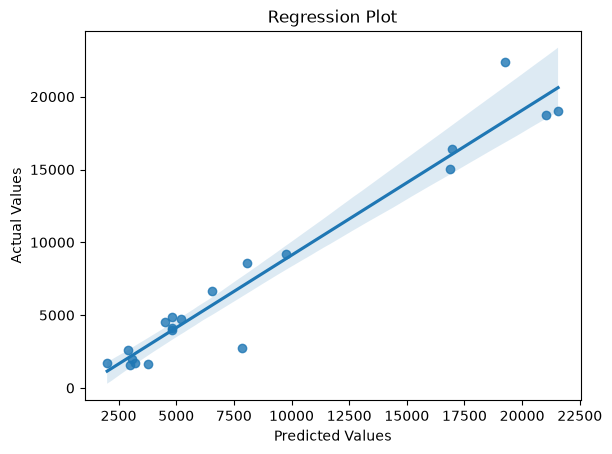

In [ ]:
sns.regplot(x= predict,y=y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Regression Plot')
plt.show()

In [ ]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.004893,0.136199,0.012840,-0.101064,-0.048781,0.418464
sex,-0.004893,1.000000,0.023310,-0.055432,-0.163012,0.099490,-0.163080
bmi,0.136199,0.023310,1.000000,-0.096297,-0.009067,0.167526,0.060666
children,0.012840,-0.055432,-0.096297,1.000000,0.088402,-0.117364,0.131640
smoker,-0.101064,-0.163012,-0.009067,0.088402,1.000000,-0.153300,0.739994
region,-0.048781,0.099490,0.167526,-0.117364,-0.153300,1.000000,-0.180849
charges,0.418464,-0.163080,0.060666,0.131640,0.739994,-0.180849,1.000000


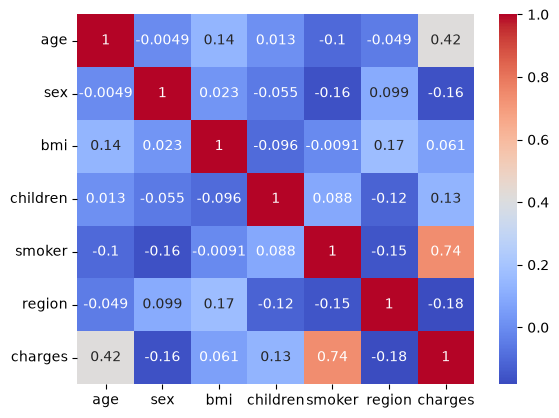

In [ ]:
sns.heatmap(data =df.corr(),annot=True,cmap= 'coolwarm')
plt.show()

In [ ]:
import pickle

with open('insurance.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI(title="Medical Insurance Prediction API")

model = joblib.load("insurance.pkl")


class InsuranceInput(BaseModel):
    age: float
    sex: int
    bmi: float
    children: int
    smoker: int
    region:str


@app.get("/")
def home():
    return {"message": "Medical Insurance Prediction API is running"}


@app.post("/predict")
def predict(data: InsuranceInput):
    features = [[
        data.age,
        data.sex,
        data.bmi,
        data.children,
        data.smoker,
        data.region
    ]]

    prediction = model.predict(features)[0]

    return {
        "predicted_insurance_cost": round(float(prediction), 2)
    }

In [ ]:
print("Train R²:", model.score(x_train, y_train))
print("Test R²:", model.score(x_test, y_test))

Train R²: 0.8578609359100023
Test R²: 0.9286001879663781


In [ ]:
idx =10
   # record number

print("Features:")
print(x.iloc[idx])

print("Actual:")
print(y.iloc[idx])

print("Predicted:")
print(model.predict(x.iloc[[idx]])[0])


Features:
age         22.00
sex          1.00
bmi         19.95
children     3.00
smoker       0.00
region       0.00
Name: 182, dtype: float64
Actual:
4005.4225
Predicted:
4816.20106283728


In [ ]:
pred = model.predict(x)

results = x.copy()
results['Actual'] = y
results['Predicted'] = pred
results['Error'] = abs(results['Actual'] - results['Predicted'])

top5 = results.sort_values('Error', ascending=False).head(5)

print(top5)

      age  sex     bmi  children  smoker  region       Actual     Predicted  \
1027   23    1  18.715         0       0       1  21595.38229   9166.135571   
128    32    0  17.765         2       1       1  32734.18630  21476.292345   
1080   18    1  21.780         2       0       2  11884.04858   5834.846486   
28     23    1  17.385         1       0       1   2775.19215   7846.697841   
1191   41    0  21.755         1       0       0  13725.47184   9856.237663   

             Error  
1027  12429.246719  
128   11257.893955  
1080   6049.202094  
28     5071.505691  
1191   3869.234177  


In [ ]:
print("95th percentile:",
np.percentile(errors,95))
print("99th percentile:",
np.percentile(errors,99))

95th percentile: 3240.54542659885
99th percentile: 4705.313638320955
